In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib Inline
%config IlineBackend.figure_format = "svg"

In [39]:
df = pd.read_csv("data/Smarket.csv")

In [4]:
print(f"The shape of the data set is {df.shape}")

The shape of the data set is (1250, 9)


In [5]:
df.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


- Year - date
- Lag1 - 1 day before
- Lag2 - 2 days before
- Lag3 - 3 days before
- Lag4 - 4 days before
- Lag5 - 5 days before
- Volume - the amount of shares traded on the previous day
- Today - the current percent
-  Direction - whether the market was Up or Down

In [12]:
print("Descriptive statistics")
df.describe()

Descriptive statistics


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1250 non-null   int64  
 1   Lag1       1250 non-null   float64
 2   Lag2       1250 non-null   float64
 3   Lag3       1250 non-null   float64
 4   Lag4       1250 non-null   float64
 5   Lag5       1250 non-null   float64
 6   Volume     1250 non-null   float64
 7   Today      1250 non-null   float64
 8   Direction  1250 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 88.0+ KB


In [20]:
numeric_df = df.drop(columns=["Direction"], axis=0)

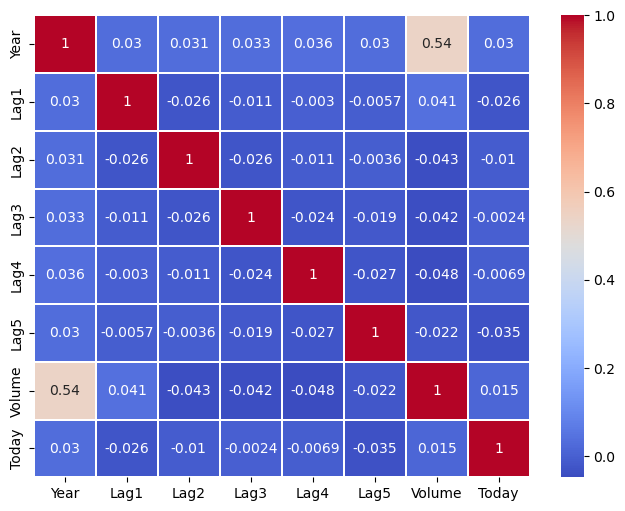

In [30]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(data=correlation_matrix, annot=True, linewidths=0.3, cmap="coolwarm")

plt.show()

The only sabstatial correlation is between Volume and Year. It means the avarage number of shares traided dailty increased from 2001 to 2005

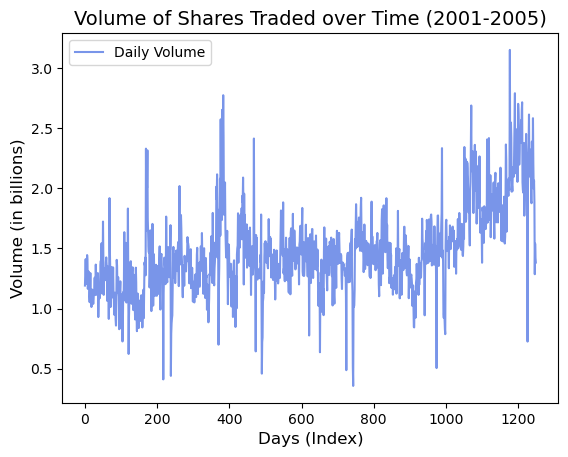

In [33]:
plt.plot(df["Volume"], color="royalblue", alpha=0.7, label="Daily Volume")

plt.title("Volume of Shares Traded over Time (2001-2005)", fontsize=14)
plt.xlabel("Days (Index)", fontsize=12)
plt.ylabel("Volume (in billions)", fontsize=12)
plt.legend()
plt.show()

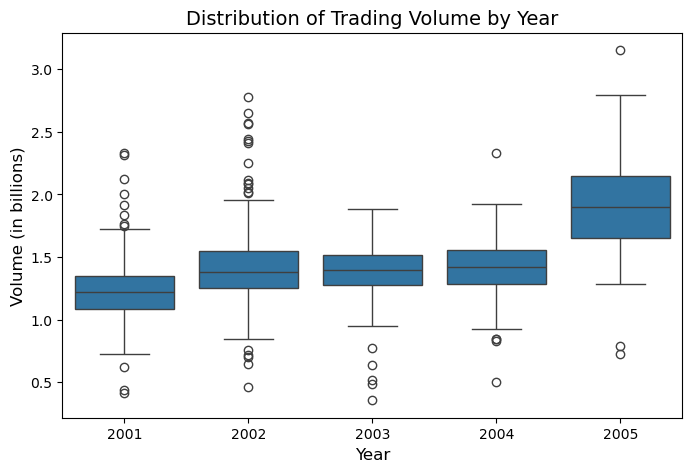

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Year", y="Volume")

plt.title("Distribution of Trading Volume by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Volume (in billions)", fontsize=12)

plt.show()

### Logistic Regression

Next, we will fit a logistic regression model in order to predict Direction
using Lag1 through Lag5 and Volume.

In [36]:
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, accuracy_score

In [40]:
df["Direction_Bin"] = (df["Direction"] == "Up").astype(int)

In [43]:
model_all = smf.logit("Direction_Bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume", data=df).fit()
print(model_all.summary())

Optimization terminated successfully.
         Current function value: 0.691034
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_Bin   No. Observations:                 1250
Model:                          Logit   Df Residuals:                     1243
Method:                           MLE   Df Model:                            6
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                0.002074
Time:                        18:31:42   Log-Likelihood:                -863.79
converged:                       True   LL-Null:                       -865.59
Covariance Type:            nonrobust   LLR p-value:                    0.7319
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1260      0.241     -0.523      0.601      -0.598       0.346
Lag1          -0.0731      0.

The smallest p-value here is associated with Lag1. The negative coefficient
for this predictor suggests that if the market had a positive return yesterday,
then it is less likely to go up today. However, at a value of 0.15, the p-value
is still relatively large, and so there is no clear evidence of a real association
between Lag1 and Direction.

In [45]:
# Get the probability for the whole sample P(Y=1|X)
pred_probs_all = model_all.predict()
# Trasnform the probabilities to classes
pred_labels_all = (pred_probs_all > 0.5).astype(int)

In [47]:
# Build the confusion matrix
confusion_matrix_all = confusion_matrix(df["Direction_Bin"], pred_labels_all)
print("The confusion matrix")
print(pd.DataFrame(confusion_matrix_all, index=["Actual Down (0)", "Actual Up (1)"], columns=["Pred Down (0)", "Pred Up (1)"]))

The confusion matrix
                 Pred Down (0)  Pred Up (1)
Actual Down (0)            145          457
Actual Up (1)              141          507


In [48]:
train_accuracy = accuracy_score(df["Direction_Bin"], pred_labels_all)
print(f"\nThe train accuracy: {train_accuracy:.4f} (or {train_accuracy*100:.1f}%)")


The train accuracy: 0.5216 (or 52.2%)


Hence our model
correctly predicted that the market would go up on 507 days and that
it would go down on 145 days, for a total of 507 + 145 = 652 correct
predictions. In this case, logistic regression
correctly predicted the movement of the market 52.2 % of the time.

At first glance, it appears that the logistic regression model is working
a little better than random guessing. However, this result is misleading
because we trained and tested the model on the same set of 1, 250 observations. In other words, 100 − 52.2 = 47.8 % is the training error rate. As we
have seen previously, the training error rate is often overly optimistic—it
tends to underestimate the test error rate. In order to better assess the accuracy of the logistic regression model in this setting, we can fit the model
using part of the data, and then examine how well it predicts the held out
data. This will yield a more realistic error rate, in the sense that in practice we will be interested in our model’s performance not on the data that
we used to fit the model, but rather on days in the future for which the
market’s movements are unknown.

To implement this strategy, we will first create a vector corresponding
to the observations from 2001 through 2004. We will then use this vector
to create a held out data set of observations from 2005.

In [51]:
df_train = df.loc[df["Year"] < 2005, :]
df_test = df.loc[df["Year"] == 2005, :]

In [58]:
model_train = smf.logit("Direction_Bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume", data=df_train).fit()
predictions_probabilities_test = model_train.predict(df_test)
predicted_labels_test = (predictions_probabilities_test > 0.5).astype(int)

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4


In [59]:
test_accuracy = accuracy_score(df_test["Direction_Bin"], predicted_labels_test)
test_error = 1 - test_accuracy
print("\n--- РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (2005 год) ---")
print(f"Test accuracy: {test_accuracy:.4f} (or {test_accuracy*100:.1f}%)")
print(f"Test Error Rate: {test_error:.4f} (or {test_error*100:.1f}%)")


--- РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (2005 год) ---
Test accuracy: 0.4802 (or 48.0%)
Test Error Rate: 0.5198 (or 52.0%)


In [55]:
confusion_matrix_test = confusion_matrix(df_test["Direction_Bin"], predicted_labels_test)
print("\Confusion matrix 2005:")
print(pd.DataFrame(confusion_matrix_test, index=['Actual Down (0)', 'Actual Up (1)'], columns=['Pred Down (0)', 'Pred Up (1)']))

\Confusion matrix 2005:
                 Pred Down (0)  Pred Up (1)
Actual Down (0)             77           34
Actual Up (1)               97           44


The results are rather disappointing: the test error
rate is 52 %, which is worse than random guessing! Of course this result
is not all that surprising, given that one would not generally expect to be
able to use previous days’ returns to predict future market performance.
(After all, if it were possible to do so, then the authors of this book would
be out striking it rich rather than writing a statistics textbook.)

We recall that the logistic regression model had very underwhelming p-values associated with all of the predictors, and that the smallest p-value,
though not very small, corresponded to Lag1. Perhaps by removing the
variables that appear not to be helpful in predicting Direction, we can
obtain a more effective model. After all, using predictors that have no
relationship with the response tends to cause a deterioration in the test
error rate (since such predictors cause an increase in variance without a
corresponding decrease in bias), and so removing such predictors may in
turn yield an improvement.

In [60]:
model_refit = smf.logit("Direction_Bin ~ Lag1 + Lag2", data=df_train).fit()
predicted_probabilities_test = model_refit.predict(df_test)
predicted_labels_test = (predicted_probabilities_test > 0.5).astype(int)

Optimization terminated successfully.
         Current function value: 0.692085
         Iterations 3


In [61]:
refit_accuracy = accuracy_score(df_test["Direction_Bin"], predicted_labels_test)
print("\n--- Limited model (Lag1 + Lag2) ---")
print(f"New test accuracy 2005: {refit_accuracy:.4f} (or {refit_accuracy*100:.1f}%)")


--- Limited model (Lag1 + Lag2) ---
New test accuracy 2005: 0.5595 (or 56.0%)


In [62]:
confusion_matrix_refir = confusion_matrix(df_test["Direction_Bin"], predicted_labels_test)
print("\nNew confusion matrix:")
print(pd.DataFrame(confusion_matrix_refir, index=['Actual Down (0)', 'Actual Up (1)'], columns=['Pred Down (0)', 'Pred Up (1)']))


New confusion matrix:
                 Pred Down (0)  Pred Up (1)
Actual Down (0)             35           76
Actual Up (1)               35          106


Now the results appear to be a little better: 56% of the daily movements
have been correctly predicted. It is worth noting that in this case, a much
simpler strategy of predicting that the market will increase every day will
also be correct 56% of the time! Hence, in terms of overall error rate, the
logistic regression method is no better than the naive approach. However,
the confusion matrix shows that on days when logistic regression predicts
an increase in the market, it has a 58% accuracy rate. This suggests a
possible trading strategy of buying on days when the model predicts an increasing market, and avoiding trades on days when a decrease is predicted.
Of course one would need to investigate more carefully whether this small
improvement was real or just due to random chance.

Suppose that we want to predict the returns associated with particular
values of Lag1 and Lag2. In particular, we want to predict Direction on a
day when Lag1 and Lag2 equal 1.2 and 1.1, respectively, and on a day when
they equal 1.5 and −0.8

In [63]:
new_days = pd.DataFrame({
    'Lag1': [1.2, 1.5],
    'Lag2': [1.1, -0.8]
})

predicted_new_probs = model_refit.predict(new_days)

print("\nPredictions for new days:")
for i, prob in enumerate(predicted_new_probs):
    print(f"Day {i+1} (Lag1={new_days.iloc[i]['Lag1']}, Lag2={new_days.iloc[i]['Lag2']}): increase probability = {prob:.4f}")


Predictions for new days:
Day 1 (Lag1=1.2, Lag2=1.1): increase probability = 0.4791
Day 2 (Lag1=1.5, Lag2=-0.8): increase probability = 0.4961


### Linear Discriminant Analysis

Now we will perform LDA on the Smarket data

In [64]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [67]:
lda = LinearDiscriminantAnalysis()
lda.fit(df_train[["Lag1", "Lag2"]], df_train["Direction_Bin"])

print("The means for each class (mu_k):")
print(pd.DataFrame(lda.means_, index=['Down', 'Up'], columns=['Lag1', 'Lag2']))
print("\nCoefficients Linear Discriminant Analysis:")
print(lda.scalings_)

The means for each class (mu_k):
          Lag1      Lag2
Down  0.042790  0.033894
Up   -0.039546 -0.031325

Coefficients Linear Discriminant Analysis:
[[-0.64201904]
 [-0.51352928]]


The LDA output indicates that ˆπ1 = 0.492 and ˆπ2 = 0.508; in other words,
49.2 % of the training observations correspond to days during which the
market went down. It also provides the group means; these are the average
of each predictor within each class, and are used by LDA as estimates
of μk. These suggest that there is a tendency for the previous 2 days’
returns to be negative on days when the market increases, and a tendency
for the previous days’ returns to be positive on days when the market
declines. The coefficients of linear discriminants output provides the linear
combination of Lag1 and Lag2 that are used to form the LDA decision rule.
In other words, these are the multipliers of the elements of X = x. If −0.642×Lag1−0.514×Lag2 is large, then the LDA classifier will predict a market increase, and if it is small, then the LDA classifier will
predict a market decline.

In [69]:
lda_pred = lda.predict(df_test[["Lag1", "Lag2"]])
lda_probs = lda.predict_proba(df_test[["Lag1", "Lag2"]])

In [72]:
confusion_matrix_lda = confusion_matrix(df_test["Direction_Bin"], lda_pred)
print("\nConfusion matrix LDA:")
print(pd.DataFrame(confusion_matrix_lda, index=['Actual Down', 'Actual Up'], columns=['Pred Down', 'Pred Up']))


Confusion matrix LDA:
             Pred Down  Pred Up
Actual Down         35       76
Actual Up           35      106


In [73]:
lda_accuracy = accuracy_score(df_test["Direction_Bin"], lda_pred)
print(f"\nTest accuracy: {lda_accuracy:.4f}")


Test accuracy: 0.5595


As we observed, the LDA and logistic regression predictions
are almost identical.

lda_probs[:, 0] — the probability of decreasing marcet (Down)

lda_probs[:, 1] — the probability of increasing marcet (Up)

If we wanted to use a posterior probability threshold other than 50 % in
order to make predictions, then we could easily do so. For instance, suppose
that we wish to predict a market decrease only if we are very certain that the
market will indeed decrease on that day—say, if the posterior probability
is at least 90 %.

In [75]:
down_certainty = lda_probs[:, 0]
days_with_90_pct_down = np.where(down_certainty > 0.9)[0]

print(f"\nThe amount of days with probability of decreasing > 90%: {len(days_with_90_pct_down)}")

print(f"The maximum confidence in decreasing: {down_certainty.max() * 100:.2f}%")


The amount of days with probability of decreasing > 90%: 0
The maximum confidence in decreasing: 52.02%


No days in 2005 meet that threshold! In fact, the greatest posterior probability of decrease in all of 2005 was 52.02 %.

### Quadratic Discriminant Analysis

We will now fit a QDA model to the Smarket data

In [76]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [89]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(df_train[["Lag1", "Lag2"]], df_train["Direction_Bin"])

print("Means for each class (mu_k):")
print(pd.DataFrame(qda.means_, index=["Down", "Up"], columns=["Lag1", "Lag2"]))

Means for each class (mu_k):
          Lag1      Lag2
Down  0.042790  0.033894
Up   -0.039546 -0.031325


In [91]:
print("\nDown covarience matrix (0):")
print(qda.covariance_[0])
print("\nUp covarience matrix (1):")
print(qda.covariance_[1])


Down covarience matrix (0):
[[ 1.50662277 -0.03924806]
 [-0.03924806  1.53559498]]

Up covarience matrix (1):
[[ 1.51700576 -0.02787349]
 [-0.02787349  1.49026815]]


The covarience vatrix are different, therefore the shapes of hills are different. This is perfect condition for QDA

In [94]:
qda_predictions = qda.predict(df_test[["Lag1", "Lag2"]])
confusion_matrix_qda = confusion_matrix(df_test["Direction_Bin"], qda_predictions)
print("\nConfusion matrix QDA:")
print(pd.DataFrame(confusion_matrix_qda, index=["Actual Down", "Actual Up"], columns=["Pred Down", "Pred Up"]))

qda_accuracy = accuracy_score(df_test["Direction_Bin"], qda_predictions)
print(f"\nTest accuracy QDA 2005: {qda_accuracy:.4f}")


Confusion matrix QDA:
             Pred Down  Pred Up
Actual Down         30       81
Actual Up           20      121

Test accuracy QDA 2005: 0.5992


even though the 2005 data was not used to fit the model. This level of accuracy is quite impressive for stock market data, which is known to be quite
hard to model accurately. This suggests that the quadratic form assumed
by QDA may capture the true relationship more accurately than the linear
forms assumed by LDA and logistic regression

### K-Nearest Neighbors

We will now perform KNN

In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
X_train = df_train[["Lag1", "Lag2"]]
X_test = df_test[["Lag1", "Lag2"]]

y_train = df_train["Direction_Bin"]
y_test = df_test["Direction_Bin"]

In [98]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
predicted_knn1 = knn1.predict(X_test)
confusion_matrix_knn1 = confusion_matrix(y_test, predicted_knn1)
print("--- KNN results K = 1 ---")
print("Confusion Matrix:")
print(pd.DataFrame(confusion_matrix_knn1, index=['Actual Down', 'Actual Up'], columns=['Pred Down', 'Pred Up']))

acc_knn1 = accuracy_score(y_test, predicted_knn1)
print(f"Accuracy K=1: {acc_knn1:.4f} (is equal {acc_knn1*100:.0f}%)")

--- KNN results K = 1 ---
Confusion Matrix:
             Pred Down  Pred Up
Actual Down         43       68
Actual Up           58       83
Accuracy K=1: 0.5000 (is equal 50%)


The results using K = 1 are not very good, since only 50% of the observations are correctly predicted. Of course, it may be that K = 1 results in an
overly flexible fit to the data. Below, we repeat the analysis using K = 3.

In [100]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
predicted_knn3 = knn3.predict(X_test)
confusion_matrix_knn3 = confusion_matrix(y_test, predicted_knn3)
print("--- KNN results K = 3 ---")
print("Confusion Matrix:")
print(pd.DataFrame(confusion_matrix_knn3, index=['Actual Down', 'Actual Up'], columns=['Pred Down', 'Pred Up']))

acc_knn3 = accuracy_score(y_test, predicted_knn3)
print(f"Accuracy K=1: {acc_knn3:.4f} (is equal {acc_knn3*100:.0f}%)")

--- KNN results K = 3 ---
Confusion Matrix:
             Pred Down  Pred Up
Actual Down         48       63
Actual Up           55       86
Accuracy K=1: 0.5317 (is equal 53%)


The results have improved slightly. But increasing K further turns out
to provide no further improvements. It appears that for this data, QDA
provides the best results of the methods that we have examined so far.